# Support ticket routing

**Recipe 04** · Level 1 (Beginner) · Decision type: `Choice`

Assign a support ticket to a fixed service category or an unclear-request outcome using its subject and description.

Sources:

- S02: [TypeSafe AI: Primitives (Questions)](https://docs.typesafe.ai/primitives)
- S03: [TypeSafe AI: Confidence](https://docs.typesafe.ai/confidence)
- S04: [TypeSafe AI: How to build with TypeSafe](https://docs.typesafe.ai/concepts/how-to-build-with-system-one)

## What you will build

A ticket router for short support messages. Jev reads a ticket's subject and description and picks exactly one of five options: four fixed service categories (`billing`, `technical_issue`, `account_access`, `feature_request`) or the explicit fallback `unclear_request`, which the use case names for a ticket that does not resolve to one category. Python decides nothing about the ticket's content; it only decides whether a chosen category is confident enough to route to its simulated queue, or should go to an explicit review outcome instead, and keeps every `unclear_request` answer out of the queues entirely, listed on its own. By the end you will have looked at individual typed answers across the full range of confidence, seen the rule that acts on them, and run an evaluation that chooses its one setting on `validation` and reports on `test`, with per-category recall and the unclear tickets discussed on their own.

## Setup and run mode

The notebook runs from its own folder with the standard library and `jev_cookbook` only. `get_backend(fixtures=...)` replays the 40 stored answers in `fixtures/responses.json` offline; setting `JEV_COOKBOOK_LIVE=1` (see the README) swaps in live calls to the same question definition and changes nothing else. `run_header` states which mode ran, and every number below carries that mode with it.

In [1]:
from jev_cookbook import get_backend, load_helpers
from jev_cookbook.evaluation import (
    accuracy,
    confusion_matrix,
    evaluate_selective,
    per_class_metrics,
    select_confidence_threshold,
)
from jev_cookbook.fixtures import load_inputs, load_labels, responses_path, select_split
from jev_cookbook.style import (
    apply_style,
    plot_answer_probabilities,
    plot_confusion_matrix,
    run_header,
    show_answer,
)

apply_style()
helpers = load_helpers()  # this recipe's helpers.py, loaded by path
examples = load_inputs()
labels = load_labels()
backend = get_backend(fixtures=responses_path())
questions = helpers.build_questions()
# N for the header is the number of examples the metrics are about: validation and test. This
# recipe has no train split; demo examples are shown but never scored.
scored = [e for e in examples if e.split not in ("train", "demo")]

offline = backend.mode in ("synthetic", "scripted")
check = " (a pipeline check, not a Jev result)" if offline else ""
# CONTRIBUTING.md section 2: "a number from the validation split is a selection step, not a
# result." This label does not depend on the run mode, unlike `check` above: even a recorded or
# live run must not print a bare validation number.
selection = " (a selection step, not a reported result)"

# Every one of the 40 examples in fixtures/ needs at most one request. This cache makes sure a
# ticket that is shown individually and later scored in its split is decided once, so the whole
# notebook makes exactly 40 requests in live mode, never more.
answered = {}


def decide(example):
    if example.id not in answered:
        answered[example.id] = backend.decide(helpers.build_state(example.fields), questions)[
            "category"
        ]
    return answered[example.id]


run_header(
    4,
    "Support ticket routing",
    backend=backend,
    n_examples=len(scored),
)

Recipe 04: Support ticket routing
Mode: offline replay of synthetic fixtures, pipeline check on a fixture sample of 38 examples
Metrics in this run are checks that the pipeline works. They are not Jev results.


## The state

The state is everything Jev sees, and Python builds it. Each example in `fixtures/inputs.jsonl` carries `fields`: a `ticket_id`, a `subject`, and a `description`. `build_state` passes on the subject and description only, as two separate fields rather than one concatenated string, so a word in the subject is never mixed with the body; the identifier stays in Python and is attached to the outcome at the end, so it never passes through the model and every result still traces back to its ticket.

In [2]:
import json

demo = {e.id: e for e in examples if e.split == "demo"}
example = demo["d01-ambiguous"]
print("Python has:")
print(json.dumps(example.fields, indent=2))
state = helpers.build_state(example.fields)
print("Jev sees:")
print(json.dumps(state, indent=2))

Python has:
{
  "ticket_id": "TKT-3001",
  "subject": "Can't update payment because locked out",
  "description": "I need to switch my card on file, but the account portal won't let me sign in at all."
}
Jev sees:
{
  "subject": "Can't update payment because locked out",
  "description": "I need to switch my card on file, but the account portal won't let me sign in at all."
}


## The questions

There is one question, and it asks one thing: which service category does this ticket belong to? A `Choice` fits because the five outcomes are exclusive and Jev should commit to exactly one. Four of the five are the fixed service categories the catalog's use case names: `billing`, `technical_issue`, `account_access`, `feature_request`. The fifth, `unclear_request`, is the explicit fallback outcome the use case also names, for a ticket that does not give enough information, raises several unrelated requests, or is not about the product or the account at all ([S02](https://docs.typesafe.ai/primitives) describes `Choice` as picking exactly one option from a fixed, known set with no inherent order; the option set here is built by Python, not invented by the model). Each option's description says what belongs to it and, for the two pairs that are easiest to confuse — a payment question against a sign-in question, and a broken feature against a requested one — what belongs to the other option instead.

A `Choice` answer's `confidence` is the top probability rescaled by the number of options, `(p_max - 1/n) / (1 - 1/n)`: with five options, 0 when the top option holds no more than a fifth of the probability, 1 when one option holds all of it. It depends only on that top probability, not on how the remaining probability is spread across the other four options, so two answers with the same top probability have the same confidence whether the rest is spread evenly or piled onto a single runner-up. A low confidence here does not mean a ticket is unreadable; it means the top option did not pull far ahead of an even fifth, which, for a short or genuinely ambiguous ticket, is often the honest shape for the probabilities to take.

[S04](https://docs.typesafe.ai/concepts/how-to-build-with-system-one) frames this kind of decision as one narrow judgment embedded in code that keeps control flow: Jev picks a category, and Python (`route_ticket` in `helpers.py`, below) decides what that category is allowed to do — route to a simulated queue, or not.

In [3]:
category = questions["category"]
print(category.instructions)
for name, description in category.criteria.items():
    print(f"  {name:16s} {description}")

Which service category does this support ticket belong to?
  billing          The ticket is about a charge, invoice, payment method, subscription renewal, or refund. A request to change who can sign in or what they can do belongs to account_access instead, even if the ticket also mentions a charge.
  technical_issue  The ticket reports the product failing to work as built: an error message, a crash, a page or feature that does not load, or data that looks wrong. A request for a capability the product does not have belongs to feature_request instead.
  account_access   The ticket is about signing in, resetting a password, two-factor codes, or who is allowed to use the account. A charge or invoice question belongs to billing instead, even if the customer also mentions being logged out.
  feature_request  The ticket asks for a capability the product does not currently have, or a change to how it behaves by design. A report that an existing feature is broken belongs to technical_issue inst

## One answer up close

Before any aggregate number, look at three typed answers across the range this recipe covers: a ticket that could plausibly be `billing` or `account_access`, a vague one-line ticket, and one this recipe's stored answer gets wrong. Each answer holds the chosen option, a probability for every option, the `confidence` explained above, and a `provenance` line that says where the answer came from, here always `synthetic`, since nothing in this recipe's fixtures came from a real call.

Choice: billing (confidence 0.27)
  billing          0.42  ########
  account_access   0.38  ########
  unclear_request  0.12  ##
  technical_issue  0.05  #
  feature_request  0.03  #
Provenance: synthetic


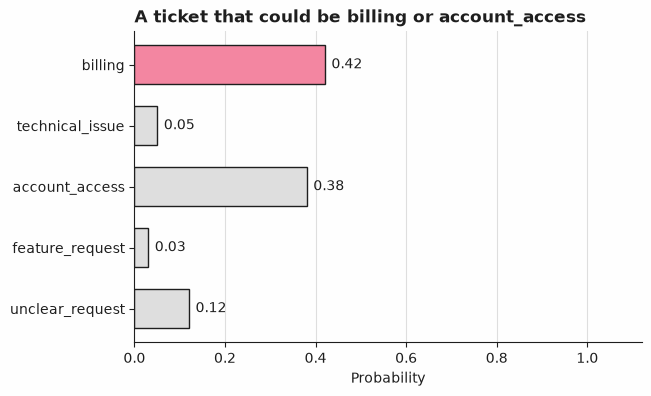

In [4]:
ambiguous_example = demo["d01-ambiguous"]
ambiguous_answer = decide(ambiguous_example)
show_answer(ambiguous_answer)
plot_answer_probabilities(
    ambiguous_answer, title="A ticket that could be billing or account_access"
)

The ticket is about changing a payment method, but the customer frames the whole thing around being locked out, so the stored answer puts `billing` only just ahead of `account_access`, 0.42 against 0.38, for a `confidence` of only 0.275: `(0.42 - 0.2) / 0.8`. This recipe's [gold label](../../docs/glossary.md#gold-label) — the correct answer recorded for evaluation, decided in advance by the rule each option's description states, not by the model — calls it `billing`, since the request itself (update the card on file) is a billing action and the lockout is what is blocking it, not what the customer is asking to fix — but a reader could reasonably disagree, which is exactly why the probabilities are this close instead of confidently one-sided.

In [5]:
vague_example = demo["d02-vague"]
vague_answer = decide(vague_example)
show_answer(vague_answer)

Choice: unclear_request (confidence 0.21)
  unclear_request  0.37  #######
  technical_issue  0.30  ######
  billing          0.15  ###
  account_access   0.12  ##
  feature_request  0.06  #
Provenance: synthetic


"please help" / "it doesn't work" carries almost no signal about which category fits, and the probabilities show it: `unclear_request` leads, but `technical_issue` is not far behind, because "it doesn't work" also sounds like a product failure. A vague ticket like this one is a hard case on purpose; there is often not enough text for any classifier, human or model, to place it in one category with confidence.

In [6]:
wrong_example = next(e for e in examples if e.id == "v08-ambiguous-bug-feature")
wrong_answer = decide(wrong_example)
print(wrong_example.fields["subject"])
print(wrong_example.fields["description"])
show_answer(wrong_answer)

Dark mode looks broken
I turned on dark mode and the text is unreadable; it would be great if this were fixed, or if you added a proper dark theme option.
Choice: feature_request (confidence 0.33)
  feature_request  0.46  #########
  technical_issue  0.34  #######
  unclear_request  0.12  ##
  account_access   0.05  #
  billing          0.03  #
Provenance: synthetic


Dark mode making text unreadable is a product failure: something that already exists is broken. The ticket also asks for "a proper dark theme option," though, and the stored answer leans the other way, calling it `feature_request` at 0.46 against `technical_issue`'s 0.34. This recipe's gold label is `technical_issue`, by the rule each option's description states (a report that an existing feature is broken belongs to `technical_issue`, even when it is framed as a suggestion); the evaluation below counts this one as wrong, on purpose. Nothing here says *why* a real model would read it this way, because nothing here is a real model: the probabilities were written by hand for this fixture, not produced by Jev.

## Python's part

Jev supplies the judgment; what happens with it is code. `route_ticket` in `helpers.py` sends a confident real-category answer to its simulated queue, sends `unclear_request` to a separate, un-queued outcome whatever its confidence (`unclear_request` is listed separately, never run past a confidence gate meant for a queue it will never enter), and sends anything else below the threshold to an explicit `review` outcome. `tests/test_helpers.py` checks the rule at the boundary, outside `0` to `1`, for a confident and a low-confidence answer of every one of the four real categories, and for `unclear_request` at both a high and a low confidence, so a rule that quietly exempted one category from the threshold, or started gating `unclear_request` on confidence after all, would fail it.

The threshold itself is chosen here, on `validation`, and then frozen for the rest of this notebook: `select_confidence_threshold` picks the lowest threshold whose answered subset is perfectly accurate on the 19 `validation` tickets, which is as much coverage as this fixture set allows without accepting a wrong answer *on validation*. Applying that frozen threshold to the three answers shown above, plus one clearly `billing` ticket for contrast, shows all three outcomes the rule can produce.

In [7]:
val_examples = select_split(examples, "validation")
val_answers = [decide(e) for e in val_examples]
val_gold = [labels[e.id] for e in val_examples]
val_correct = [a.choice == g for a, g in zip(val_answers, val_gold, strict=True)]
val_confidence = [a.confidence for a in val_answers]
threshold = select_confidence_threshold(val_correct, val_confidence, target_accuracy=1.0)
print(f"chosen threshold, frozen from here on: {threshold:.4f}{selection}{check}")

confident_example = next(e for e in val_examples if e.id == "v01-billing")
confident_answer = decide(confident_example)
for shown_example, shown_answer in (
    (ambiguous_example, ambiguous_answer),
    (vague_example, vague_answer),
    (wrong_example, wrong_answer),
    (confident_example, confident_answer),
):
    result = helpers.route_ticket(shown_example.fields["ticket_id"], shown_answer, threshold)
    print(
        f"{result.ticket_id}: {shown_answer.choice} at confidence {shown_answer.confidence:.2f} "
        f"-> {result.outcome} ({result.reason})"
    )

chosen threshold, frozen from here on: 0.3750 (a selection step, not a reported result) (a pipeline check, not a Jev result)
TKT-3001: billing at confidence 0.27 -> review (confidence below the threshold)
TKT-3002: unclear_request at confidence 0.21 -> unclear (the ticket does not resolve to one category)
TKT-1008: feature_request at confidence 0.33 -> review (confidence below the threshold)
TKT-1001: billing at confidence 0.87 -> routed (confident match)


## Evaluation

The threshold was chosen and frozen above, on `validation`. This section reports what the frozen rule does: `helpers.route_ticket` is applied to every example in `validation` and in `test`, and the counts below come from what it actually returns, not from a separate reimplementation of the same condition. Alongside that, `jev_cookbook.evaluation` reports accuracy of the raw choice, a confusion matrix against the gold labels, per-category precision and recall, and the coverage, accuracy and risk the frozen threshold produces on `test`. In an offline run every `test` number here is a check that the pipeline works, and it says so; every `validation` number, in every run mode, is a selection step rather than a reported result, which is why it carries a different label.

In [8]:
def report(chosen, decided, threshold):
    """Apply route_ticket to every answer and tally what it actually did."""
    results = [
        helpers.route_ticket(e.fields["ticket_id"], a, threshold)
        for e, a in zip(chosen, decided, strict=True)
    ]
    counts = {helpers.ROUTED: 0, helpers.REVIEW: 0, helpers.UNCLEAR: 0}
    for r in results:
        counts[r.outcome] += 1
    return results, counts


val_results, val_counts = report(val_examples, val_answers, threshold)
print(f"validation, {len(val_examples)} examples{selection}{check}")
print(f"accuracy of the choice: {accuracy(val_gold, val_answers):.4f}{selection}{check}")
print(
    f"routed: {val_counts[helpers.ROUTED]}, review: {val_counts[helpers.REVIEW]}, "
    f"unclear: {val_counts[helpers.UNCLEAR]} (of {len(val_examples)}){selection}{check}"
)
val_unclear = [r for r in val_results if r.outcome == helpers.UNCLEAR]
print(f"unclear on validation, listed separately{selection}{check}:")
for r in val_unclear:
    print(f"  {r.ticket_id}: {r.reason}")

validation, 19 examples (a selection step, not a reported result) (a pipeline check, not a Jev result)
accuracy of the choice: 0.9474 (a selection step, not a reported result) (a pipeline check, not a Jev result)
routed: 14, review: 2, unclear: 3 (of 19) (a selection step, not a reported result) (a pipeline check, not a Jev result)
unclear on validation, listed separately (a selection step, not a reported result) (a pipeline check, not a Jev result):
  TKT-1011: the ticket does not resolve to one category
  TKT-1012: the ticket does not resolve to one category
  TKT-1013: the ticket does not resolve to one category


In [ ]:
test_examples = select_split(examples, "test")
test_answers = [decide(e) for e in test_examples]
test_gold = [labels[e.id] for e in test_examples]

test_results, test_counts = report(test_examples, test_answers, threshold)
print(f"test, {len(test_examples)} examples, threshold {threshold:.4f} frozen{check}")
print(f"accuracy of the choice: {accuracy(test_gold, test_answers):.4f}{check}")
print(
    f"routed: {test_counts[helpers.ROUTED]}, review: {test_counts[helpers.REVIEW]}, "
    f"unclear: {test_counts[helpers.UNCLEAR]} (of {len(test_examples)}){check}"
)

matrix = confusion_matrix(test_gold, test_answers, labels=list(helpers.OPTIONS))
width = max(len(label) for label in matrix.labels)
# The header's leader ("predicted ->") and each row's leader ("gold <label>") are
# different fixed phrases; padding both to the same leader_width, derived from this
# same width, is what keeps the header's columns and every row's columns lined up,
# whatever width this recipe's own labels turn out to need.
leader_width = max(width + len("gold "), len("predicted ->"))
header = "  ".join(f"{label:>{width}s}" for label in matrix.labels)
print(f"test confusion matrix, gold rows by predicted columns{check}:")
print(f"  {'predicted ->':<{leader_width}s}  {header}{check}")
for gold_label, row in zip(matrix.labels, matrix.matrix.tolist(), strict=True):
    counts = "  ".join(f"{count:{width}d}" for count in row)
    leader = f"gold {gold_label:<{width}s}"
    print(f"  {leader:<{leader_width}s}  {counts}{check}")
plot_confusion_matrix(matrix, title=f"Test split, {len(test_examples)} examples{check}")

Two of `test`'s nineteen tickets are wrong. "Export only works for PDF" (`t08-ambiguous-bug-feature`) reports an existing export button not responding in the same sentence as a request for a new format; this recipe's gold label is `technical_issue` (an existing feature is broken), but the stored answer calls it `feature_request` at a confidence of 0.775, comfortably above the frozen threshold, so the rule routes it to the `product-queue` anyway. "A few things" (`t13-mixed-topics`) mixes an invoice complaint, a search bug, and a sort-order request; the gold label is `unclear_request` (it does not resolve to one category), and the stored answer instead leans toward `billing` — but only at a confidence of 0.125, well below the threshold, so the rule sends it to `review` instead of reporting a wrong result. That pattern, one error the threshold catches and one it does not, is the point of the selective-prediction numbers further down.

For each category, `precision` is the fraction of the rule's calls of that label that were actually right, and `recall` is the fraction of that label's real `test` tickets the rule found at all; `f1` is their harmonic mean, a single number that is low whenever either one is, and `support` is how many `test` tickets actually carry that gold label, so a recall figure is only as meaningful as its support is large.

In [10]:
per_class = per_class_metrics(test_gold, test_answers, labels=list(helpers.OPTIONS))
for label, counts in per_class.items():
    print(
        f"{label:16s} precision {counts.precision:.3f}  recall {counts.recall:.3f}  "
        f"f1 {counts.f1:.3f}  support {counts.support}{check}"
    )

billing          precision 0.833  recall 1.000  f1 0.909  support 5 (a pipeline check, not a Jev result)
technical_issue  precision 1.000  recall 0.750  f1 0.857  support 4 (a pipeline check, not a Jev result)
account_access   precision 1.000  recall 1.000  f1 1.000  support 4 (a pipeline check, not a Jev result)
feature_request  precision 0.750  recall 1.000  f1 0.857  support 3 (a pipeline check, not a Jev result)
unclear_request  precision 1.000  recall 0.667  f1 0.800  support 3 (a pipeline check, not a Jev result)


How the unclear tickets were handled: three of `test`'s nineteen tickets have the gold label `unclear_request`. `route_ticket` calls two of them `unclear_request` too and lists them separately below, with no queue; the third, `t13-mixed-topics` above, is called `billing` instead — its raw choice is simply wrong, and that alone is what costs `unclear_request` its recall, independently of what the rule then does with a wrong choice. What the rule does with it here is a separate fact: `t13`'s confidence, 0.125, is well below the frozen threshold, so this particular wrong choice is caught and sent to `review` rather than routed anywhere; a wrong choice confident enough to clear the threshold (like `t08` above) would miss `unclear_request`'s recall the same way while being routed instead of reviewed. `unclear_request`'s own recall on `test`, from the table above, reflects only the first fact: two of its three tickets are found by the raw choice, the third is not, before the threshold enters into it at all.

In [11]:
unclear_tickets = [r for r in test_results if r.outcome == helpers.UNCLEAR]
print(f"unclear_request tickets, listed separately, never queued{check}:")
for r in unclear_tickets:
    print(f"  {r.ticket_id}: {r.reason}")

unclear_request tickets, listed separately, never queued (a pipeline check, not a Jev result):
  TKT-2011: the ticket does not resolve to one category
  TKT-2012: the ticket does not resolve to one category


The `routed`/`review`/`unclear` counts above come straight from `route_ticket`; `evaluate_selective` reports a related number through `jev_cookbook.evaluation`'s own vocabulary, over every `test` ticket regardless of category. `coverage` is the fraction of all nineteen `test` tickets whose confidence clears the threshold; among those, `accuracy` is the fraction that are right, and `risk` is its complement, `1 - accuracy`, the fraction that are wrong despite having cleared the bar.

In [12]:
test_correct = [a.choice == g for a, g in zip(test_answers, test_gold, strict=True)]
test_confidence = [a.confidence for a in test_answers]
selective = evaluate_selective(test_correct, test_confidence, threshold)
print(
    f"answered: {selective.n_answered} of {selective.n_total} "
    f"(coverage {selective.coverage:.4f}){check}"
)
print(f"accuracy among those answered: {selective.accuracy:.4f}{check}")
print(f"risk among those answered: {selective.risk:.4f}{check}")

answered: 15 of 19 (coverage 0.7895) (a pipeline check, not a Jev result)
accuracy among those answered: 0.9333 (a pipeline check, not a Jev result)
risk among those answered: 0.0667 (a pipeline check, not a Jev result)


`risk` above is not zero: `t08-ambiguous-bug-feature`'s confidence, 0.775, clears the threshold frozen on `validation`, so the rule answers it and the answer is wrong. A threshold chosen to be perfectly accurate on `validation` is a guarantee about `validation`, not about `test` or about any ticket this recipe has not seen. The coverage side of the trade still holds here: most of `test`'s tickets clear the threshold, and most of the ones that do not would have been right anyway; the accuracy side does not, on purpose, so this recipe does not teach a threshold as a guarantee it is not.

## What was and was not measured

Measured: that the pipeline runs end to end, and that the rule and the evaluation behave as designed on 38 scored tickets (plus 2 more, shown in this notebook but never scored). Not measured: anything about how Jev performs, how fast it is, or what it costs. The stored answers in the offline run are written by hand as probabilities, two of them wrong on purpose (one wrong and confident, to show what a frozen threshold does not catch; one wrong but not confident, to show what it does), so every number above describes this fixture set and not a model.

In [13]:
if offline:
    print(f"Provenance: {backend.mode}. Not measured live: a pipeline check, not a Jev result.")
else:
    dates = ", ".join(getattr(backend, "recorded_dates", ()) or ()) or "this run"
    print(f"Provenance: {backend.mode}, model {backend.model}")
    print(f"Captured: {dates}")
    print(f"N: {len(val_examples)} validation and {len(test_examples)} test examples")

Provenance: synthetic. Not measured live: a pipeline check, not a Jev result.


## Next steps

- Add a hard ticket to `ROWS` in `build_fixtures.py` with the answer you expect a model might give, run `python build_fixtures.py`, and see where `route_ticket` sends it.
- Change the threshold's target in the evaluation cell (`target_accuracy=1.0` to something looser) and see how coverage and the review count trade off.
- Neighbouring recipes: [`01-sentiment-classification`](../01-sentiment-classification/) and [`05-document-classification`](../05-document-classification/), which build on a `Choice` over a fixed option set like this one; [`02-refund-intent-detection`](../02-refund-intent-detection/) for a `Noul` question instead.